<a href="https://colab.research.google.com/github/davi-aoliveira/Sistemas-T-rmicos/blob/main/compressor_minimos_quadrados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# O SISTEMA
# Compressor de Ar de Dois Estágios com Intercooler
### Solução por **Mínimos Quadrados Não-Lineares (Gauss-Newton)** — Problema 6.15

<p align="center">
  <img src="https://drive.google.com/uc?id=1yR5gwzZ9YXgZE_XYwkYbD5QQcqiF9uV2" width="600"><figcaption><center>Figura 1: Sistema Térmico</figcaption></figure>
</p>

---

## O que está acontecendo na máquina?

Comprimir ar de 100 kPa até 1200 kPa de uma vez só é ineficiente porque o ar aquece muito durante a compressão, e ar quente ocupa mais volume — você precisa de mais trabalho para comprimir o mesmo gás. A solução é dividir em dois estágios e resfriar o ar no meio do caminho.

```
Ar frio → [Compressor Baixo] → Ar quente (P₂) → [Intercooler] → Ar resfriado (P₂) → [Compressor Alto] → Ar final (P₄)
```

O intercooler é um trocador de calor: o ar quente passa por um lado, água fria passa pelo outro, e calor é removido do ar.

---

## AS 4 EQUAÇÕES FÍSICAS

O sistema tem 4 incógnitas que não conhecemos: $\dot{w}$ (vazão de ar), $P_2$ (pressão intermediária), $T_2$ (temperatura após o 1º compressor), $T_3$ (temperatura após o intercooler).

Precisamos de 4 equações independentes para resolver.

---

## Equação 1 — Balanço de massa no estágio baixo

A vazão mássica que sai de um compressor depende de quanto volume ele desloca por segundo e de quão bem ele o faz (eficiência volumétrica):

$$\dot{w} = \frac{\eta_{low}}{100} \cdot \dot{V}_{low} \cdot \rho_1$$

- $\dot{V}_{low} = 0{,}20\ \text{m}^3/\text{s}$ é o volume deslocado pelo pistão por segundo
- $\rho_1 = P_1/(R \cdot T_1)$ é a densidade do ar na sucção (lei do gás perfeito $PV = mRT$)
- $\eta_{low}$ é a eficiência volumétrica — nem todo o volume deslocado vira ar útil, pois há gás residual nas folgas

A eficiência volumétrica depende da razão de compressão:

$$\eta\ [\%] = 104 - 4{,}0 \cdot \left(\frac{P_{saída}}{P_{entrada}}\right)^{1,4}$$

Quanto maior a razão de compressão, pior a eficiência — o gás residual nas folgas se expande mais e ocupa mais do volume de sucção.

Reescrevendo como $f_1 = 0$:

$$f_1 = \dot{w} - \frac{\eta_{low}}{100} \cdot \dot{V}_{low} \cdot \frac{P_1}{R \cdot T_1} = 0$$

---

## Equação 2 — Balanço de massa no estágio alto

Mesma lógica, mas agora o compressor aspira ar na pressão $P_2$ e temperatura $T_3$ (após o intercooler):

$$f_2 = \dot{w} - \frac{\eta_{high}}{100} \cdot \dot{V}_{high} \cdot \frac{P_2}{R \cdot T_3} = 0$$

**O que conecta as duas equações:** a mesma vazão $\dot{w}$ passa pelos dois compressores. Isso é a conservação de massa em regime permanente — o que entra tem que sair.

---

## Equação 3 — Temperatura após compressão politrópica

Uma compressão **politrópica** é um processo real entre dois extremos:
- **Isotérmica** ($n=1$): compressão lenta, o calor escapa totalmente
- **Isentrópica** ($n=\gamma \approx 1{,}4$): compressão rápida, sem troca de calor

Com $n = 1{,}2$ o processo é intermediário, como na prática. A relação pressão-volume é:

$$P_1 v_1^n = P_2 v_2^n$$

Combinando com a lei do gás perfeito ($Pv = RT$), a temperatura de saída é:

$$T_2 = T_1 \cdot \left(\frac{P_2}{P_1}\right)^{\frac{n-1}{n}}$$

Reescrevendo como $f_3 = 0$:

$$f_3 = T_2 - T_1 \cdot \left(\frac{P_2}{P_1}\right)^{\frac{n-1}{n}} = 0$$

Esta equação é puramente geométrica/termodinâmica — ela diz que $T_2$ não é livre, está determinada por $P_2$.

---

## Equação 4 — Balanço de energia no intercooler (método ε-NTU)

O intercooler é um trocador contracorrente: ar e água fluem em sentidos opostos. Para calcular o calor transferido sem conhecer as temperaturas de saída diretamente, usamos o método **ε-NTU**.

**Passo 1 — Capacidades térmicas:**

$$C_{ar} = \dot{w} \cdot c_{p,ar} \qquad C_{água} = \dot{m}_w \cdot c_{p,água}$$

**Passo 2 — NTU** (Número de Unidades de Transferência):

$$NTU = \frac{UA}{C_{min}}$$

NTU mede o "tamanho" do trocador relativo à capacidade do fluido mais fraco. UA = 0,3 kW/K é fornecido diretamente.

**Passo 3 — Efetividade** (para trocador contracorrente):

$$\varepsilon = \frac{1 - e^{-NTU(1-C_r)}}{1 - C_r \cdot e^{-NTU(1-C_r)}} \qquad \text{onde } C_r = \frac{C_{min}}{C_{max}}$$

A efetividade $\varepsilon \in [0,1]$ responde: "qual fração do máximo possível de calor está sendo transferida?"

**Passo 4 — Calor real e temperatura de saída:**

$$Q = \varepsilon \cdot C_{min} \cdot (T_2 - T_{w,entrada})$$

$$T_3 = T_2 - \frac{Q}{C_{ar}}$$

Reescrevendo como $f_4 = 0$:

$$f_4 = T_3 - T_{3,calculado}(T_2, \dot{w}) = 0$$

---


## Fundamentação do Método

O problema consiste em resolver o sistema $\mathbf{F}(\mathbf{x}) = \mathbf{0}$, com 4 equações e 4 incógnitas.  
Em vez de resolver diretamente (como no Newton-Raphson), o **método dos mínimos quadrados** reformula o problema como **minimização de uma função objetivo escalar**:

$$S(\mathbf{x}) = \sum_{i=1}^{4} f_i(\mathbf{x})^2 = \|\mathbf{F}(\mathbf{x})\|^2$$

A solução do sistema original $\mathbf{F}(\mathbf{x}) = \mathbf{0}$ corresponde ao **mínimo global** $S = 0$.

### Iteração de Gauss-Newton

Linearizando $\mathbf{F}$ ao redor de $\mathbf{x}^{(k)}$:

$$\mathbf{F}(\mathbf{x}^{(k)} + \boldsymbol{\delta}) \approx \mathbf{F}^{(k)} + \mathbf{J}^{(k)}\boldsymbol{\delta}$$

Minimizando $S = \|\mathbf{F}^{(k)} + \mathbf{J}^{(k)}\boldsymbol{\delta}\|^2$ em relação a $\boldsymbol{\delta}$ (derivada = 0):

$$\underbrace{\left(\mathbf{J}^T \mathbf{J}\right)}_{\text{matriz de informação}} \boldsymbol{\delta} = -\mathbf{J}^T \mathbf{F} \quad \leftarrow \text{equações normais}$$

Atualização com passo amortecido (line search) para garantir $S^{(k+1)} < S^{(k)}$:

$$\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} + \alpha^* \boldsymbol{\delta}$$

> **Diferença fundamental vs. Newton-Raphson:**  
> - NR resolve $\mathbf{J}\boldsymbol{\delta} = -\mathbf{F}$ — passo exato no espaço das equações.  
> - Gauss-Newton resolve $\mathbf{J}^T\mathbf{J}\,\boldsymbol{\delta} = -\mathbf{J}^T\mathbf{F}$ — passo ótimo no sentido dos **mínimos quadrados**, mais robusto com chutes ruins e permite monitorar $S(\mathbf{x})$ como métrica quantitativa de qualidade da solução.

---

**Variáveis de estado:** $\mathbf{x} = [\dot{w},\ P_2,\ T_2,\ T_3]$

```
Ar (P1,T1) → [Estágio Baixo] → (P2,T2) → [Intercooler] → (P2,T3) → [Estágio Alto] → (P4,T4)
                                                 ↑
                                       Água (Tw_in, ṁw)
```

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  Colab: descomente se necessário
# !pip install numpy matplotlib -q
# ─────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('✔ Bibliotecas importadas.')

✔ Bibliotecas importadas.


## 1. Parâmetros do Sistema
> ✏️ **Modifique os valores abaixo para explorar diferentes configurações.**

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  PARÂMETROS DO SISTEMA — ALTERE AQUI
# ═══════════════════════════════════════════════════════════════

# ── Condições de contorno ───────────────────────────────────────
P1 = 100.0              # kPa   — pressão de sucção
T1 = 26.0 + 273.15      # K     — temperatura de entrada (26 °C)
P4 = 1200.0             # kPa   — pressão de descarga final

# ── Compressores ────────────────────────────────────────────────
V_low  = 0.20           # m³/s  — deslocamento estágio baixo
V_high = 0.05           # m³/s  — deslocamento estágio alto
n_poly = 1.2            # (-)   — expoente politrópico

# Eficiência volumétrica: η% = A - B*(P_disc/P_succ)^exp_eta
A_eta   = 104.0
B_eta   = 4.0
exp_eta = 1.4

# ── Intercooler ─────────────────────────────────────────────────
UA       = 0.30         # kW/K  — produto UA
Tw_in    = 22.0 + 273.15# K     — temperatura entrada da água
m_w      = 0.09         # kg/s  — vazão da água
cp_water = 4.18         # kJ/(kg·K)

# ── Propriedades do ar (gás perfeito) ───────────────────────────
R_air  = 0.287          # kJ/(kg·K)
cp_air = 1.005          # kJ/(kg·K)

# ═══════════════════════════════════════════════════════════════
#  PARÂMETROS DO SOLVER (MÍNIMOS QUADRADOS — GAUSS-NEWTON)
# ═══════════════════════════════════════════════════════════════
max_iter       = 50     # máximo de iterações
tol_S          = 1e-10  # tolerância na função objetivo S(x)
tol_dx         = 1e-8   # tolerância no passo ||δx||
h_jac          = 1e-6   # passo para Jacobiano numérico
alpha_init     = 1.0    # passo inicial do line search
alpha_min      = 1e-6   # passo mínimo
beta_backtrack = 0.5    # fator de redução do passo
lambda_damp    = 1e-6   # amortecimento de Levenberg-Marquardt (regularização)

# ─────────────────────────────────────────────────────────────────
#  Chute inicial  x0 = [w, P2, T2, T3]
# ─────────────────────────────────────────────────────────────────
P2_0 = np.sqrt(P1 * P4)
T2_0 = T1 * (P2_0 / P1) ** ((n_poly - 1) / n_poly)
T3_0 = T1 + 10.0
eta0 = A_eta - B_eta * (P2_0 / P1) ** exp_eta
w_0  = (eta0 / 100) * V_low * P1 / (R_air * T1)

x0 = np.array([w_0, P2_0, T2_0, T3_0])

print('─' * 55)
print(' Chute inicial x₀:')
print(f'   ẇ   = {x0[0]:.5f} kg/s')
print(f'   P₂  = {x0[1]:.3f}  kPa')
print(f'   T₂  = {x0[2]:.3f}  K  ({x0[2]-273.15:.1f} °C)')
print(f'   T₃  = {x0[3]:.3f}  K  ({x0[3]-273.15:.1f} °C)')
print('─' * 55)

───────────────────────────────────────────────────────
 Chute inicial x₀:
   ẇ   = 0.18921 kg/s
   P₂  = 346.410  kPa
   T₂  = 367.977  K  (94.8 °C)
   T₃  = 309.150  K  (36.0 °C)
───────────────────────────────────────────────────────


## 2. Modelo Físico

In [ ]:
def eta_vol(P_disc, P_succ):
    """Eficiência volumétrica [%]"""
    return A_eta - B_eta * (P_disc / P_succ) ** exp_eta


def T_polytropic(T_in, P_out, P_in):
    """Temperatura de saída da compressão politrópica."""
    return T_in * (P_out / P_in) ** ((n_poly - 1) / n_poly)


def intercooler(T_hot_in, w_air):
    """
    Intercooler contracorrente — método ε-NTU.
    Retorna: Q [kW], efetividade ε, temperatura de saída do ar T3 [K]
    """
    C_ar  = w_air * cp_air
    C_agu = m_w   * cp_water
    C_min, C_max = sorted([C_ar, C_agu])
    Cr  = C_min / C_max
    NTU = UA / C_min

    if abs(Cr - 1.0) < 1e-9:
        eps = NTU / (1.0 + NTU)
    else:
        ev  = np.exp(-NTU * (1.0 - Cr))
        eps = (1.0 - ev) / (1.0 - Cr * ev)

    Q  = eps * C_min * (T_hot_in - Tw_in)
    T3 = T_hot_in - Q / C_ar
    return Q, eps, T3


def F(x):
    """
    Sistema de equações não-lineares F(x) = 0
    x = [w, P2, T2, T3]

    f1 — balanço de massa estágio baixo
    f2 — balanço de massa estágio alto
    f3 — temperatura politrópica estágio baixo
    f4 — balanço de energia no intercooler
    """
    w, P2, T2, T3 = x

    eta_L = eta_vol(P2, P1)
    eta_H = eta_vol(P4, P2)
    rho1  = P1 / (R_air * T1)
    rho3  = P2 / (R_air * T3)

    f1 = w - (eta_L / 100.0) * V_low  * rho1
    f2 = w - (eta_H / 100.0) * V_high * rho3
    f3 = T2 - T_polytropic(T1, P2, P1)

    _, _, T3_ic = intercooler(T2, w)
    f4 = T3 - T3_ic

    return np.array([f1, f2, f3, f4])


def S(x):
    """Função objetivo S(x) = ||F(x)||²  — minimizar até S → 0"""
    fv = F(x)
    return float(fv @ fv)


def jacobian(x, h=h_jac):
    """Jacobiano por diferenças finitas centrais: J[i,j] = ∂fᵢ/∂xⱼ"""
    n = len(x)
    J = np.zeros((n, n))
    for j in range(n):
        xp = x.copy(); xp[j] += h
        xm = x.copy(); xm[j] -= h
        J[:, j] = (F(xp) - F(xm)) / (2.0 * h)
    return J


print('✔ Modelo físico definido.')
print(f'  S(x₀) = {S(x0):.6f}  →  deve convergir para ≈ 0')

✔ Modelo físico definido.
  S(x₀) = 55.995941  →  deve convergir para ≈ 0


## 3. Solver — Gauss-Newton com Levenberg-Marquardt e Backtracking Line Search

A cada iteração $k$:

1. Calcula $\mathbf{J}^{(k)}$ e $\mathbf{F}^{(k)}$
2. Resolve as **equações normais regularizadas**:
$$\left(\mathbf{J}^T\mathbf{J} + \lambda\mathbf{I}\right)\boldsymbol{\delta} = -\mathbf{J}^T\mathbf{F}$$
3. **Backtracking**: encontra $\alpha \in (0,1]$ tal que $S(\mathbf{x}+\alpha\boldsymbol{\delta}) < S(\mathbf{x})$
4. Atualiza $\mathbf{x} \leftarrow \mathbf{x} + \alpha\boldsymbol{\delta}$
5. Para quando $S(\mathbf{x}) < $ `tol_S` ou $\|\alpha\boldsymbol{\delta}\| < $ `tol_dx`

In [ ]:
def gauss_newton(x0, max_iter=50, tol_S=1e-10, tol_dx=1e-8,
                 alpha_init=1.0, alpha_min=1e-6, beta=0.5,
                 lam=1e-6, verbose=True):
    """
    Minimiza S(x) = ||F(x)||² usando Gauss-Newton + L-M + line search.

    Equações normais:  (JᵀJ + λI) δ = −JᵀF
    Atualização:       x ← x + α·δ

    Retorna
    -------
    x_sol, hist_x, hist_S, hist_alpha, hist_cond, converged, n_iter
    """
    x          = x0.copy().astype(float)
    hist_x     = [x.copy()]
    hist_S     = [S(x)]
    hist_alpha = [np.nan]
    hist_cond  = [np.nan]
    converged  = False
    n_iter     = 0

    sep = '─' * 62
    hdr = f"{'Iter':>5}  {'S(x)':>14}  {'||α·δx||':>12}  {'α':>8}  {'cond(JᵀJ)':>12}"

    if verbose:
        print(sep)
        print(hdr)
        print(sep)
        print(f"{'0':>5}  {hist_S[0]:>14.6e}  {'—':>12}  {'—':>8}  {'—':>12}")

    for k in range(1, max_iter + 1):
        Fk  = F(x)
        Jk  = jacobian(x)

        # ── Equações normais (mínimos quadrados) ──────────────────
        JtJ   = Jk.T @ Jk
        JtF   = Jk.T @ Fk
        A_reg = JtJ + lam * np.eye(len(x))   # regularização L-M
        cond  = np.linalg.cond(JtJ)

        try:
            delta = np.linalg.solve(A_reg, -JtF)
        except np.linalg.LinAlgError:
            if verbose:
                print('⚠ Sistema singular — iteração interrompida.')
            break

        # ── Backtracking line search ──────────────────────────────
        alpha  = alpha_init
        S_curr = S(x)
        while alpha > alpha_min:
            if S(x + alpha * delta) < S_curr:
                break
            alpha *= beta

        x       = x + alpha * delta
        S_new   = S(x)
        dx_norm = np.linalg.norm(alpha * delta)

        hist_x.append(x.copy())
        hist_S.append(S_new)
        hist_alpha.append(alpha)
        hist_cond.append(cond)
        n_iter = k

        if verbose:
            print(f"{k:>5}  {S_new:>14.6e}  {dx_norm:>12.6e}  "
                  f"{alpha:>8.5f}  {cond:>12.4e}")

        # ── Critérios de parada ───────────────────────────────────
        if S_new < tol_S:
            converged = True
            if verbose:
                print(sep)
                print(f'  ✔ Convergiu em {k} iter  [S(x) = {S_new:.2e} < tol_S = {tol_S:.0e}]')
            break
        if dx_norm < tol_dx:
            converged = True
            if verbose:
                print(sep)
                print(f'  ✔ Convergiu em {k} iter  [||δx|| = {dx_norm:.2e} < tol_dx = {tol_dx:.0e}]')
            break

    if not converged and verbose:
        print(sep)
        print('  ⚠  Número máximo de iterações atingido.')

    if verbose:
        print(sep)

    return x, hist_x, hist_S, hist_alpha, hist_cond, converged, n_iter


# ── Executar ──────────────────────────────────────────────────────
x_sol, hist_x, hist_S, hist_alpha, hist_cond, converged, n_iter = gauss_newton(
    x0,
    max_iter       = max_iter,
    tol_S          = tol_S,
    tol_dx         = tol_dx,
    alpha_init     = alpha_init,
    alpha_min      = alpha_min,
    beta           = beta_backtrack,
    lam            = lambda_damp,
)

──────────────────────────────────────────────────────────────
 Iter            S(x)      ||α·δx||         α     cond(JᵀJ)
──────────────────────────────────────────────────────────────
    0    5.599594e+01             —         —             —
    1    1.879150e-02  1.119647e+01   1.00000    7.2539e+10
    2    3.330448e-04  7.643039e+00   1.00000    8.7819e+10
    3    1.541688e-04  5.831129e+00   1.00000    8.9845e+10
    4    7.855956e-05  4.452503e+00   1.00000    9.1541e+10
    5    4.226882e-05  3.401917e+00   1.00000    9.2810e+10
    6    2.354071e-05  2.600406e+00   1.00000    9.3767e+10
    7    1.338705e-05  1.988410e+00   1.00000    9.4489e+10
    8    7.707319e-06  1.520831e+00   1.00000    9.5037e+10
    9    4.469484e-06  1.163426e+00   1.00000    9.5454e+10
   10    2.602830e-06  8.901424e-01   1.00000    9.5771e+10
   11    1.519512e-06  6.811265e-01   1.00000    9.6012e+10
   12    8.883683e-07  5.212334e-01   1.00000    9.6196e+10
   13    5.198227e-07  3.989001e-0

## 4. Resultados

In [ ]:
w_s, P2_s, T2_s, T3_s = x_sol

Q_ic, eps_ic, _ = intercooler(T2_s, w_s)
T4_s   = T_polytropic(T3_s, P4, P2_s)
Tw_out = Tw_in + Q_ic / (m_w * cp_water)

eta_L = eta_vol(P2_s, P1)
eta_H = eta_vol(P4,  P2_s)

def W_comp(w, T_in, P_out, P_in):
    """Potência politrópica [kW]"""
    return w * (n_poly/(n_poly-1)) * R_air * T_in * ((P_out/P_in)**((n_poly-1)/n_poly) - 1)

W_low    = W_comp(w_s, T1,   P2_s, P1)
W_high   = W_comp(w_s, T3_s, P4,   P2_s)
W_total  = W_low + W_high
W_simple = W_comp(w_s, T1,   P4,   P1)   # sem intercooler

print('\n' + '═'*60)
print('  SOLUÇÃO — MÍNIMOS QUADRADOS (Gauss-Newton)')
print('═'*60)
print(f'  Convergência em {n_iter} iterações    S(x*) = {S(x_sol):.3e}')
print('─'*60)
print(f'  ẇ   = {w_s:.6f} kg/s')
print(f'  P₂  = {P2_s:.4f}  kPa')
print(f'  T₂  = {T2_s:.4f}  K    ({T2_s-273.15:.2f} °C)')
print(f'  T₃  = {T3_s:.4f}  K    ({T3_s-273.15:.2f} °C)')
print()
print('  GRANDEZAS DERIVADAS')
print('─'*60)
print(f'  T₄ (saída estágio alto)  = {T4_s:.4f} K   ({T4_s-273.15:.2f} °C)')
print(f'  Temp. saída da água      = {Tw_out-273.15:.4f} °C')
print(f'  η_vol estágio baixo      = {eta_L:.4f} %')
print(f'  η_vol estágio alto       = {eta_H:.4f} %')
print(f'  Razão compressão low     = {P2_s/P1:.4f}')
print(f'  Razão compressão high    = {P4/P2_s:.4f}')
print(f'  Calor intercooler  Q     = {Q_ic:.4f} kW')
print(f'  Efetividade ε            = {eps_ic:.4f}')
print()
print(f'  Ẇ estágio baixo          = {W_low:.4f} kW')
print(f'  Ẇ estágio alto           = {W_high:.4f} kW')
print(f'  Ẇ total (2 estágios)     = {W_total:.4f} kW')
print(f'  Ẇ compressão simples     = {W_simple:.4f} kW')
print(f'  Economia com intercooler = {100*(W_simple-W_total)/W_simple:.2f} %')
print('═'*60)

print('\n  Resíduos finais F(x*):')
for i, fi in enumerate(F(x_sol)):
    print(f'    f{i+1} = {fi:+.3e}')


════════════════════════════════════════════════════════════
  SOLUÇÃO — MÍNIMOS QUADRADOS (Gauss-Newton)
════════════════════════════════════════════════════════════
  Convergência em 30 iterações    S(x*) = 5.864e-11
────────────────────────────────────────────────────────────
  ẇ   = 0.180120 kg/s
  P₂  = 387.8019  kPa
  T₂  = 374.9649  K    (101.81 °C)
  T₃  = 317.1581  K    (44.01 °C)

  GRANDEZAS DERIVADAS
────────────────────────────────────────────────────────────
  T₄ (saída estágio alto)  = 382.8579 K   (109.71 °C)
  Temp. saída da água      = 49.8156 °C
  η_vol estágio baixo      = 77.3244 %
  η_vol estágio alto       = 84.5527 %
  Razão compressão low     = 3.8780
  Razão compressão high    = 3.0944
  Calor intercooler  Q     = 10.4642 kW
  Efetividade ε            = 0.7243

  Ẇ estágio baixo          = 23.5153 kW
  Ẇ estágio alto           = 20.3779 kW
  Ẇ total (2 estágios)     = 43.8932 kW
  Ẇ compressão simples     = 47.6074 kW
  Economia com intercooler = 7.80 %
═════

## 5. Visualizações da Convergência

/tmp/ipykernel_10142/3136063863.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


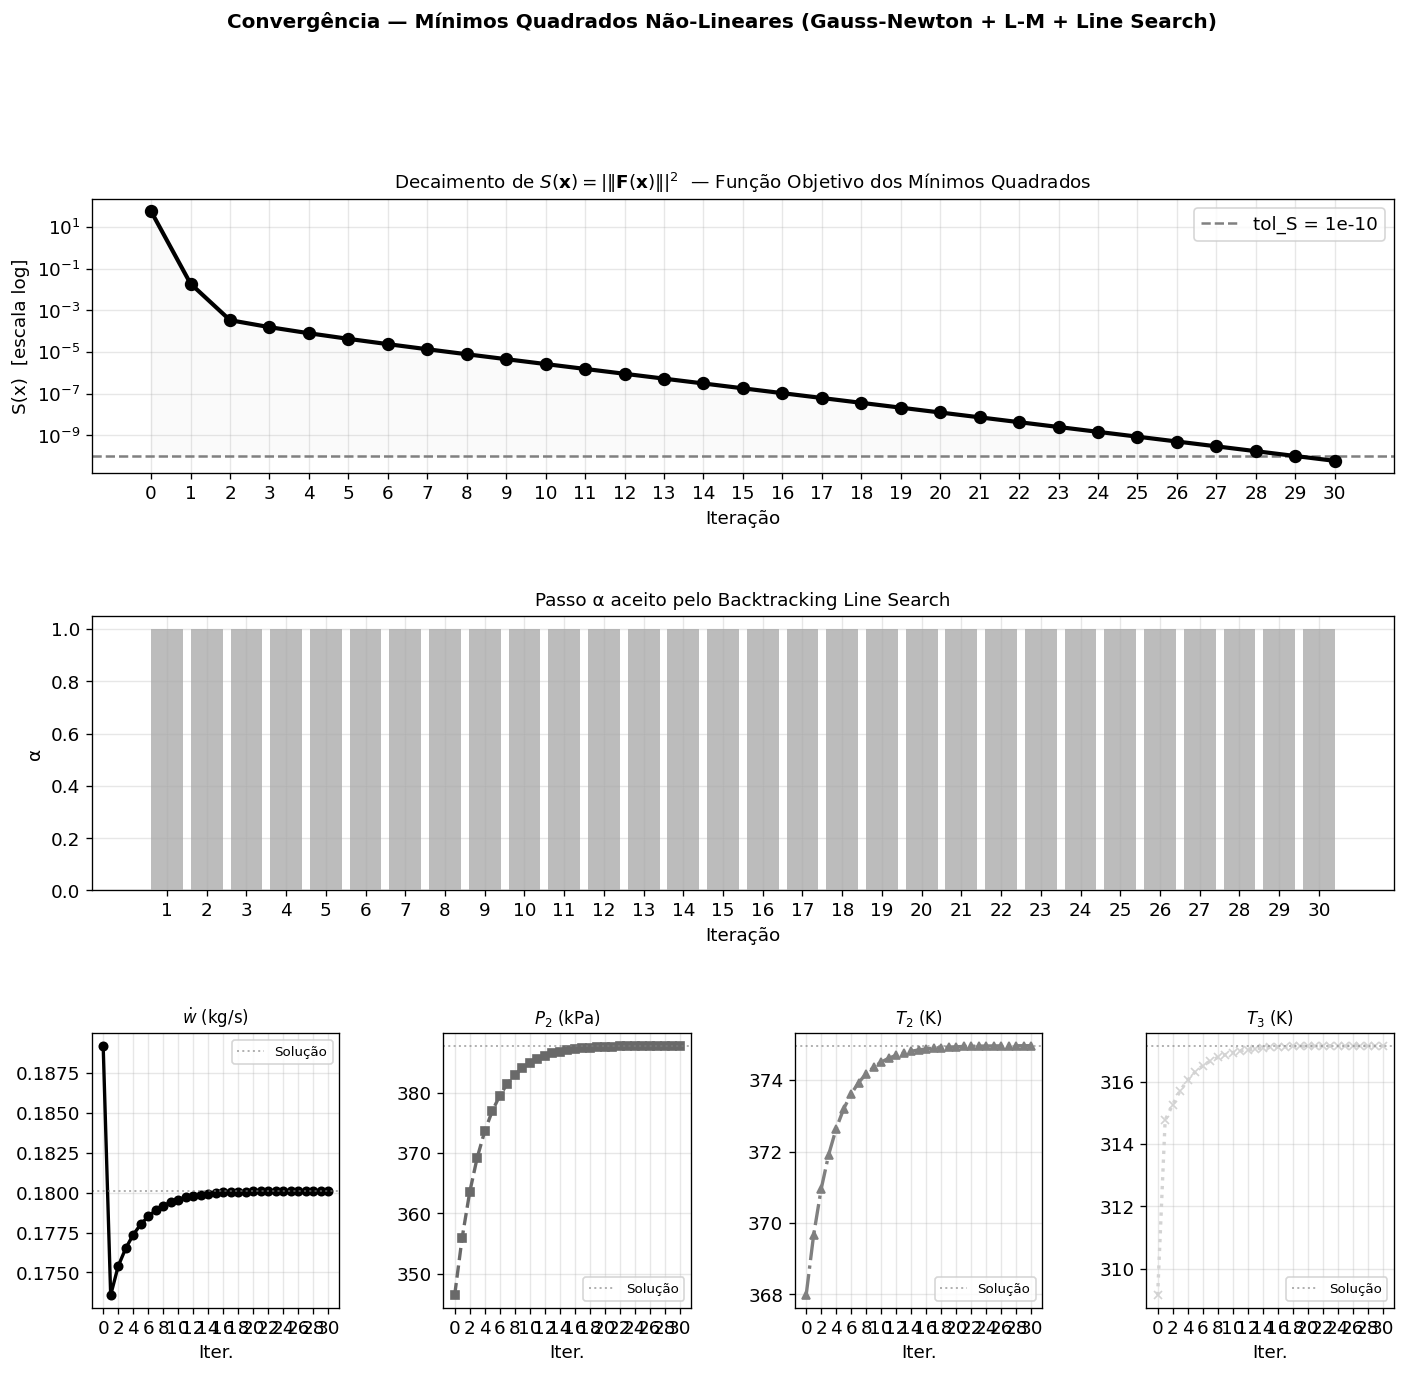

In [ ]:
hist   = np.array(hist_x)
iters  = np.arange(len(hist_S))
labels = [r'$\dot{w}$ (kg/s)', r'$P_2$ (kPa)', r'$T_2$ (K)', r'$T_3$ (K)']

# Define different plot styles for black and white
plot_styles = [
    {'marker': 'o', 'linestyle': '-', 'color': 'black'},
    {'marker': 's', 'linestyle': '--', 'color': 'dimgray'},
    {'marker': '^', 'linestyle': '-.', 'color': 'gray'},
    {'marker': 'x', 'linestyle': ':', 'color': 'lightgray'},
]

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.42)

# ── (a) S(x) — função objetivo ─────────────────────────────────
ax_S = fig.add_subplot(gs[0, :])
ax_S.semilogy(iters, hist_S, plot_styles[0]['marker'] + plot_styles[0]['linestyle'], color=plot_styles[0]['color'], lw=2.5, ms=7, zorder=3)
ax_S.axhline(tol_S, color='gray', ls='--', lw=1.5, label=f'tol_S = {tol_S:.0e}')
ax_S.fill_between(iters, hist_S, tol_S, alpha=0.10, color='lightgray')
ax_S.set_title(r'Decaimento de $S(\mathbf{x}) = |\|\mathbf{F}(\mathbf{x})\||^2$  — Função Objetivo dos Mínimos Quadrados',
               fontsize=11)
ax_S.set_xlabel('Iteração')
ax_S.set_ylabel('S(x)  [escala log]')
ax_S.legend()
ax_S.set_xticks(iters)

# ── (b) Passo α aceito ─────────────────────────────────────────
ax_a = fig.add_subplot(gs[1, :])
alphas_plot = [a if not np.isnan(a) else 0 for a in hist_alpha]
ax_a.bar(iters[1:], alphas_plot[1:], color='darkgray', alpha=0.78, zorder=3)
ax_a.set_title('Passo α aceito pelo Backtracking Line Search', fontsize=11)
ax_a.set_xlabel('Iteração')
ax_a.set_ylabel('α')
ax_a.set_xticks(iters[1:])

# ── (c-f) Evolução das variáveis ───────────────────────────────
for i in range(4):
    ax_v = fig.add_subplot(gs[2, i])
    ax_v.plot(iters, hist[:, i], **plot_styles[i], lw=2, ms=5)
    ax_v.axhline(x_sol[i], color='gray', ls=':', lw=1.2, alpha=0.6, label='Solução')
    ax_v.set_title(labels[i], fontsize=10)
    ax_v.set_xlabel('Iter.')
    ax_v.legend(fontsize=8)
    ax_v.set_xticks(iters if len(iters) <= 8 else iters[::2])

fig.suptitle('Convergência — Mínimos Quadrados Não-Lineares (Gauss-Newton + L-M + Line Search)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/conv_gn.png', bbox_inches='tight', dpi=130)
plt.show()

## 6. Superfície da Função Objetivo $S(\dot{w}, P_2)$

Mostra o "vale" que o solver percorre até $S = 0$, visualizado no plano $\dot{w} \times P_2$ (fixando $T_2, T_3$ na solução).

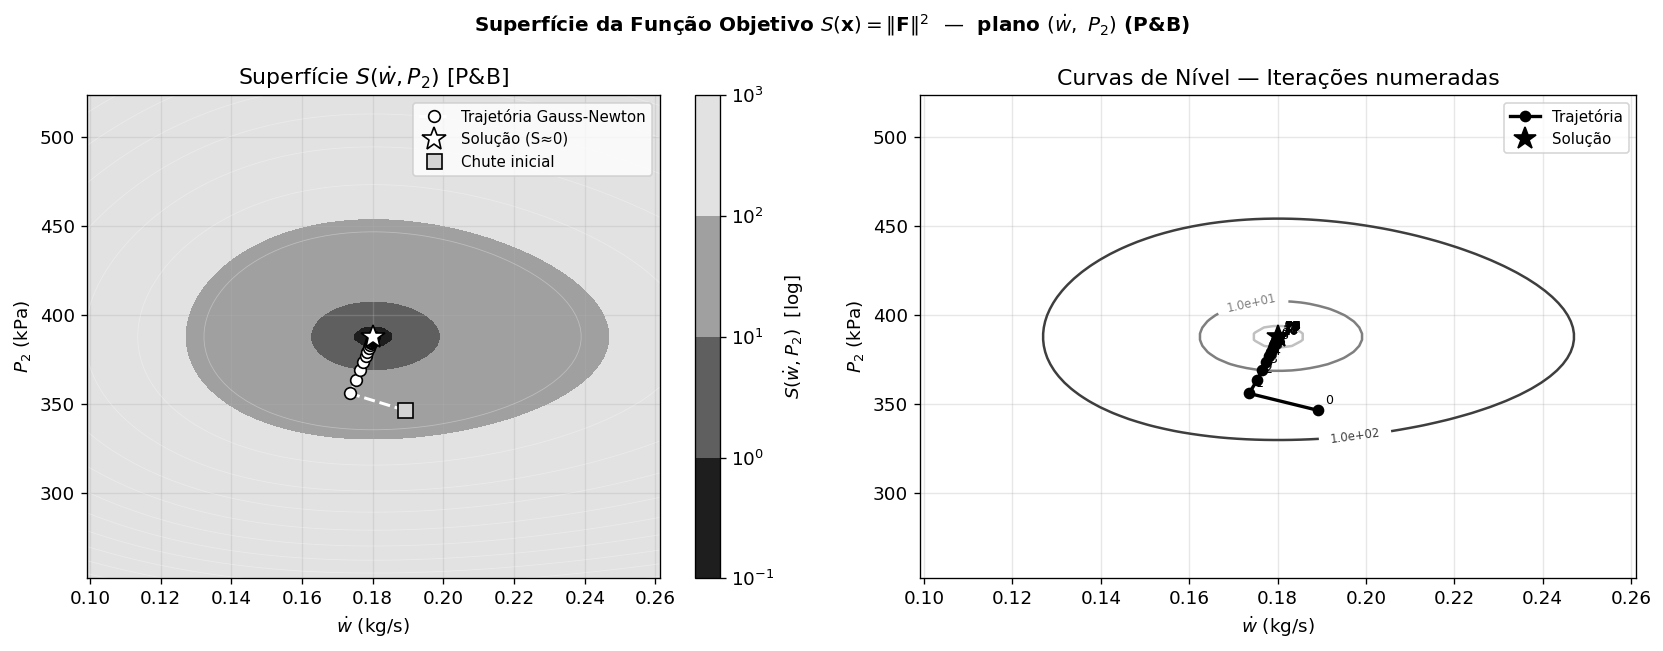

In [ ]:
N       = 80
w_grid  = np.linspace(x_sol[0]*0.55, x_sol[0]*1.45, N)
P2_grid = np.linspace(x_sol[1]*0.65, x_sol[1]*1.35, N)
WW, PP  = np.meshgrid(w_grid, P2_grid)

SS = np.array([[S(np.array([WW[i,j], PP[i,j], x_sol[2], x_sol[3]]))
                for j in range(N)] for i in range(N)])

traj_w  = hist[:, 0]
traj_P2 = hist[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Mapa de calor em tons de cinza
vmin = SS[SS > 0].min()
vmax = SS.max()
im = axes[0].contourf(WW, PP, SS, levels=50, cmap='gray',
                       norm=LogNorm(vmin=vmin, vmax=vmax))
fig.colorbar(im, ax=axes[0], label=r'$S(\dot{w}, P_2)$  [log]')
axes[0].contour(WW, PP, SS, levels=12, colors='white', linewidths=0.5, alpha=0.3)
axes[0].plot(traj_w, traj_P2, 'o--', color='white', lw=1.8, ms=7,
             label='Trajetória Gauss-Newton', markeredgecolor='black')
axes[0].plot(x_sol[0], x_sol[1], '*', color='white',   ms=15, label='Solução (S≈0)', markeredgecolor='black')
axes[0].plot(x0[0],    x0[1],    's', color='lightgray', ms=9,  label='Chute inicial', markeredgecolor='black')
axes[0].set_xlabel(r'$\dot{w}$ (kg/s)')
axes[0].set_ylabel('$P_2$ (kPa)')
axes[0].set_title(r'Superfície $S(\dot{w}, P_2)$ [P&B]')
axes[0].legend(fontsize=9)

# Curvas de nível (P&B)
cs = axes[1].contour(WW, PP, SS, levels=14, cmap='binary',
                      norm=LogNorm(vmin=vmin, vmax=vmax))
axes[1].clabel(cs, fmt='%.1e', fontsize=7)
axes[1].plot(traj_w, traj_P2, 'o-', color='black', lw=2, ms=6,
             label='Trajetória')
for k, (tw, tp) in enumerate(zip(traj_w, traj_P2)):
    axes[1].annotate(str(k), (tw, tp), fontsize=7.5,
                     textcoords='offset points', xytext=(4, 4))
axes[1].plot(x_sol[0], x_sol[1], '*', color='black', ms=14, label='Solução')
axes[1].set_xlabel(r'$\dot{w}$ (kg/s)')
axes[1].set_ylabel('$P_2$ (kPa)')
axes[1].set_title('Curvas de Nível — Iterações numeradas')
axes[1].legend(fontsize=9)

fig.suptitle(r'Superfície da Função Objetivo $S(\mathbf{x})=\|\mathbf{F}\|^2$  —  plano $(\dot{w},\ P_2)$ (P&B)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/superficie_S_bw.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. Diagrama T–P do Ciclo e Tabela de Estados

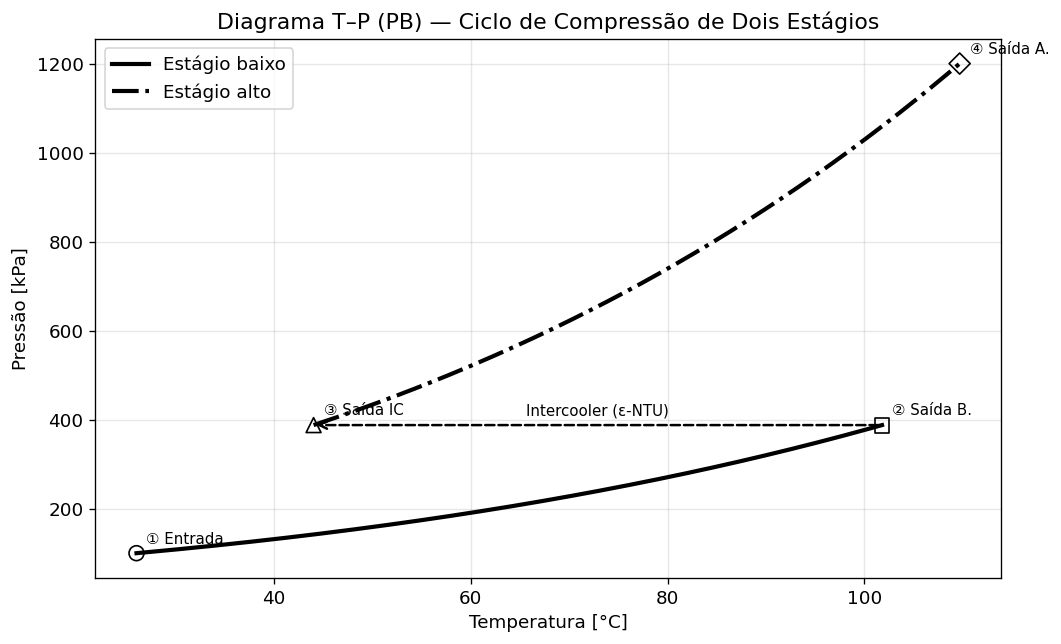


════════════════════════════════════════════════════════════════════════════
  #   Descrição                   T [K]   T [°C]   P [kPa]   ρ [kg/m³]
────────────────────────────────────────────────────────────────────────────
  1   Entrada (est. baixo)       299.15    26.00    100.00     1.16474
  2   Saída (est. baixo)         374.96   101.81    387.80     3.60361
  3   Saída (intercooler)        317.16    44.01    387.80     4.26042
  4   Saída (est. alto)          382.86   109.71   1200.00    10.92098
════════════════════════════════════════════════════════════════════════════


In [ ]:
def poly_curve(P_in, T_in, P_out, N=200):
    Pv = np.linspace(P_in, P_out, N)
    Tv = T_in * (Pv / P_in) ** ((n_poly - 1) / n_poly)
    return Tv - 273.15, Pv

Tc1, Pc1 = poly_curve(P1,   T1,   P2_s)
Tc2, Pc2 = poly_curve(P2_s, T3_s, P4)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Estágio baixo: Linha contínua preta
ax.plot(Tc1, Pc1, color='black', linestyle='-', lw=2.5, label='Estágio baixo')

# Intercooler: Seta tracejada
ax.annotate('', xy=(T3_s-273.15, P2_s), xytext=(T2_s-273.15, P2_s),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5, ls='--'))
ax.text((T2_s+T3_s)/2-273.15, P2_s*1.055,
        'Intercooler (ε-NTU)', ha='center', fontsize=9, color='black')

# Estágio alto: Linha traço-ponto preta
ax.plot(Tc2, Pc2, color='black', linestyle='-.', lw=2.5, label='Estágio alto')

pts = [
    (T1,   P1,   '① Entrada',  'o'),
    (T2_s, P2_s, '② Saída B.', 's'),
    (T3_s, P2_s, '③ Saída IC', '^'),
    (T4_s, P4,   '④ Saída A.', 'D'),
]

for Tp, Pp, rot, m in pts:
    ax.scatter(Tp-273.15, Pp, s=80, facecolors='none', edgecolors='black', marker=m, zorder=5)
    ax.annotate(rot, (Tp-273.15, Pp), textcoords='offset points',
                xytext=(6, 6), fontsize=9, color='black')

ax.set_xlabel('Temperatura [°C]')
ax.set_ylabel('Pressão [kPa]')
ax.set_title('Diagrama T–P (PB) — Ciclo de Compressão de Dois Estágios')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/diagrama_tp_bw.png', bbox_inches='tight', dpi=130)
plt.show()

# Tabela permanece inalterada
T_st  = [T1,   T2_s, T3_s, T4_s]
P_st  = [P1,   P2_s, P2_s, P4]
rho_st= [p/(R_air*t) for p,t in zip(P_st, T_st)]
desc  = ['Entrada (est. baixo)', 'Saída (est. baixo)',
         'Saída (intercooler)', 'Saída (est. alto)']

print('\n' + '═'*76)
print(f"  {'#':<3} {'Descrição':<24} {'T [K]':>8} {'T [°C]':>8} {'P [kPa]':>9} {'ρ [kg/m³]':>11}")
print('─'*76)
for i,(T,P,rho,d) in enumerate(zip(T_st,P_st,rho_st,desc),1):
    print(f'  {i:<3} {d:<24} {T:>8.2f} {T-273.15:>8.2f} {P:>9.2f} {rho:>11.5f}')
print('═'*76)

## 8. Análise de Sensibilidade
> Efeito do UA do intercooler e da pressão de descarga sobre $T_3$ e a potência total.

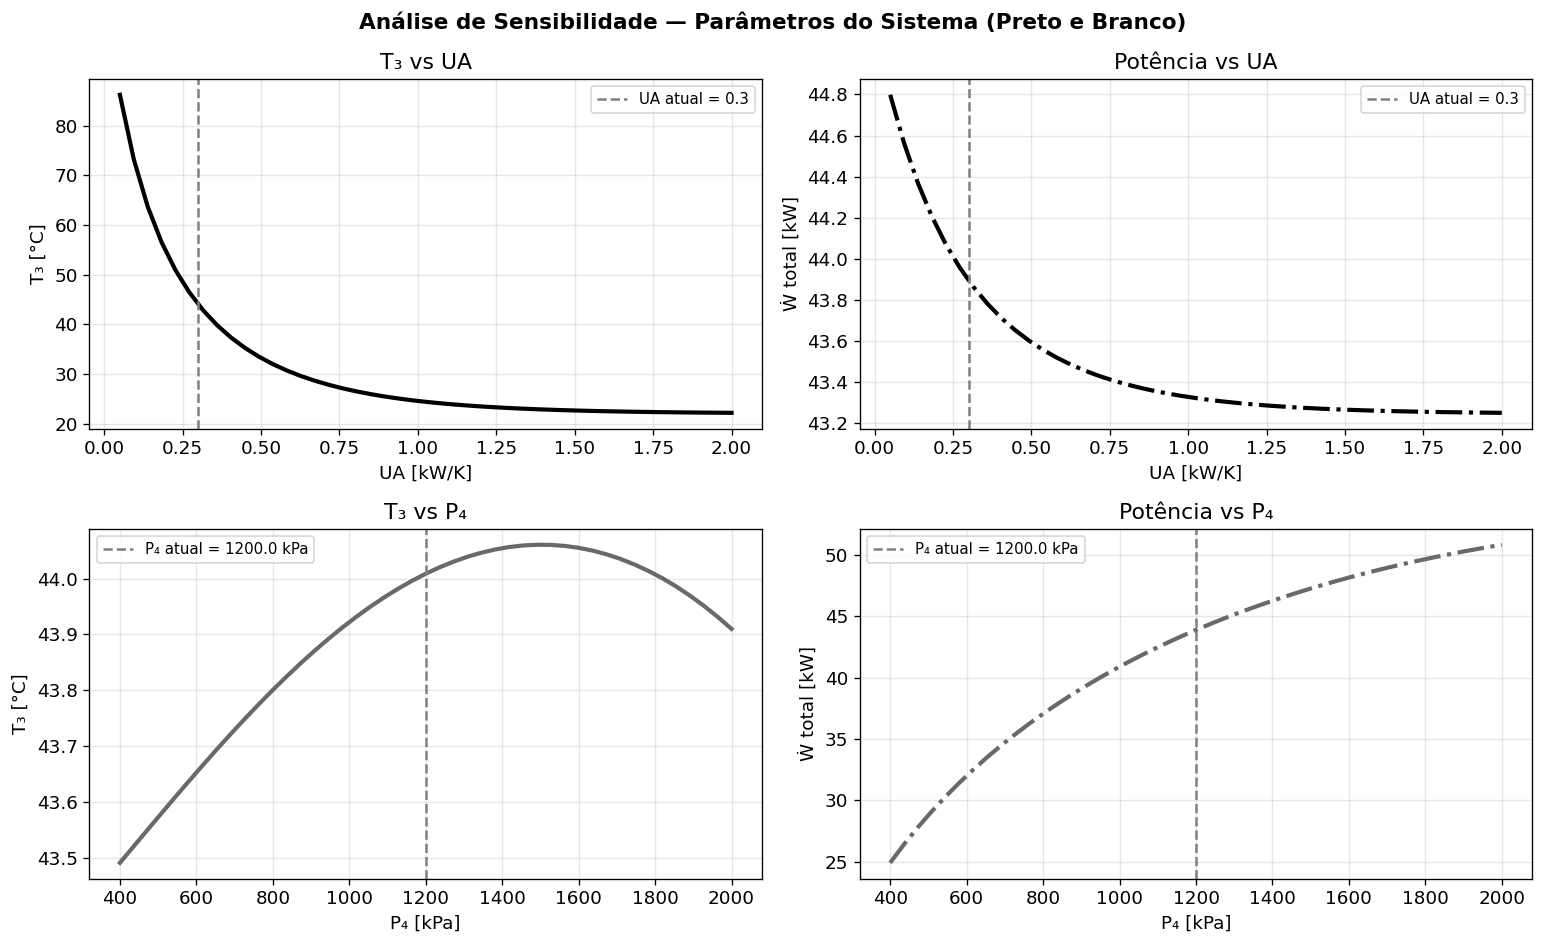

In [ ]:
def solve_with(UA_new=None, P4_new=None):
    """Re-resolve com parâmetros alterados (mantém os globais intactos)."""
    global UA, P4
    UA_orig, P4_orig = UA, P4
    if UA_new  is not None: UA  = UA_new
    if P4_new  is not None: P4  = P4_new

    P2_g = np.sqrt(P1 * P4)
    T2_g = T1 * (P2_g/P1)**((n_poly-1)/n_poly)
    eta_g = A_eta - B_eta*(P2_g/P1)**exp_eta
    w_g   = (eta_g/100)*V_low*P1/(R_air*T1)
    xi    = np.array([w_g, P2_g, T2_g, T1+10.0])

    x, *_, conv, _ = gauss_newton(
        xi, max_iter=100, tol_S=1e-12, tol_dx=1e-10,
        alpha_init=1.0, alpha_min=1e-8, beta=0.5, lam=1e-6, verbose=False
    )
    UA, P4 = UA_orig, P4_orig
    return x if conv else None

UA_vals = np.linspace(0.05, 2.0, 45)
P4_vals = np.linspace(400, 2000, 45)

T3_UA, W_UA, T3_P4, W_P4 = [], [], [], []
for ua in UA_vals:
    sol = solve_with(UA_new=ua)
    if sol is not None:
        w_, P2_, T2_, T3_ = sol
        T3_UA.append(T3_ - 273.15)
        W_UA.append(W_comp(w_,T1,P2_,P1) + W_comp(w_,T3_,P4,P2_))
    else:
        T3_UA.append(np.nan); W_UA.append(np.nan)

for p4 in P4_vals:
    sol = solve_with(P4_new=p4)
    if sol is not None:
        w_, P2_, T2_, T3_ = sol
        T3_P4.append(T3_ - 273.15)
        W_P4.append(W_comp(w_,T1,P2_,P1) + W_comp(w_,T3_,p4,P2_))
    else:
        T3_P4.append(np.nan); W_P4.append(np.nan)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Análise de Sensibilidade — Parâmetros do Sistema (Preto e Branco)', fontsize=13, fontweight='bold')

# Estilos em Preto e Branco
axes[0,0].plot(UA_vals, T3_UA,  color='black', ls='-', lw=2.5)
axes[0,0].axvline(UA, color='gray', ls='--', label=f'UA atual = {UA}')
axes[0,0].set(xlabel='UA [kW/K]', ylabel='T₃ [°C]', title='T₃ vs UA')

axes[0,1].plot(UA_vals, W_UA,   color='black', ls='-.', lw=2.5)
axes[0,1].axvline(UA, color='gray', ls='--', label=f'UA atual = {UA}')
axes[0,1].set(xlabel='UA [kW/K]', ylabel='Ẇ total [kW]', title='Potência vs UA')

axes[1,0].plot(P4_vals, T3_P4,  color='dimgray', ls='-', lw=2.5)
axes[1,0].axvline(P4, color='gray', ls='--', label=f'P₄ atual = {P4} kPa')
axes[1,0].set(xlabel='P₄ [kPa]', ylabel='T₃ [°C]', title='T₃ vs P₄')

axes[1,1].plot(P4_vals, W_P4,   color='dimgray', ls='-.', lw=2.5)
axes[1,1].axvline(P4, color='gray', ls='--', label=f'P₄ atual = {P4} kPa')
axes[1,1].set(xlabel='P₄ [kPa]', ylabel='Ẇ total [kW]', title='Potência vs P₄')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/sensibilidade_bw.png', bbox_inches='tight', dpi=130)
plt.show()